In [23]:
from tradepy.data.loader import load_future
from tradepy.config.config import load_config, load_symbols, load_feature_config, load_exclude_config
from tradepy.data.loader import load_specs
from tradepy.data.cleaner import add_trading_date_by_gap
from tradepy.data.resampler import resample_ohlcv, daily_ohlcv_cummulative
from tradepy.features.generate import generate_features
from tradepy.features.quality_check import data_quality_report
from tradepy.supervised.load import prepare_all
from tradepy.paths import EXCLUDE_CONFIG, SYSTEM_CONFIG
from tradepy.supervised.target import target_triple_barrier_interday
from tradepy.supervised.pretrain import filter_features
from tradepy.supervised.models import GoldLSTM_L1_Move, GoldLSTM_L2_Dir, GoldGRU_L1_Move, GoldGRU_L2_Dir, BasicLSTM_L1_Move, BasicLSTM_L2_Dir, BasicGRU_L1_Move, BasicGRU_L2_Dir, BasicLSTM_L3_Regression, BasicGRU_L3_Regression
from tradepy.supervised.train import train_walk_forward_2level, grid_search_thresholds, create_lstm_dataset
from tradepy.supervised.posttrain import evaluate_model_classification, tune_threshold_wf, save_trading_model_2level, load_trading_model_3level
from tradepy.supervised.backtest import prepare_bt, create_test_dataset, predict_in_batches, run_backtest_complete, run_backtest_complete_scalein, run_backtest_sizing_only, run_backtest_scalein_sizing, build_overlapping_blocks, monte_carlo_blocks, backtest_grid_search, plot_equities, max_drawdown, max_losing_streak, plot_conjunto
from tradepy.paths import MODELS_DIR, BT_DIR

import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt


In [24]:
# start = "2026-03-27"
start = "2026-01-20"
end   = "2026-06-01"

In [25]:
symbols = load_symbols()
cfg = load_config()

In [26]:
ASSET = symbols[11]
MINUTES             = cfg['sampling_minutes']        # 240
RETURN_HORIZON_MIN  = cfg['return_horizon_min']      # 2880

🚀 Pipeline 3-Level cargado correctamente desde: E:\Futuro\MLAlgoTrading\TradingBots\Models/zn/trading_model_lstm_3level
📌 Features: 65
📌 Thresholds cargados: True
📁 Resultados cargados: True
🚀 Pipeline 3-Level cargado correctamente desde: E:\Futuro\MLAlgoTrading\TradingBots\Models/zn/trading_model_gru_3level
📌 Features: 65
📌 Thresholds cargados: True
📁 Resultados cargados: True


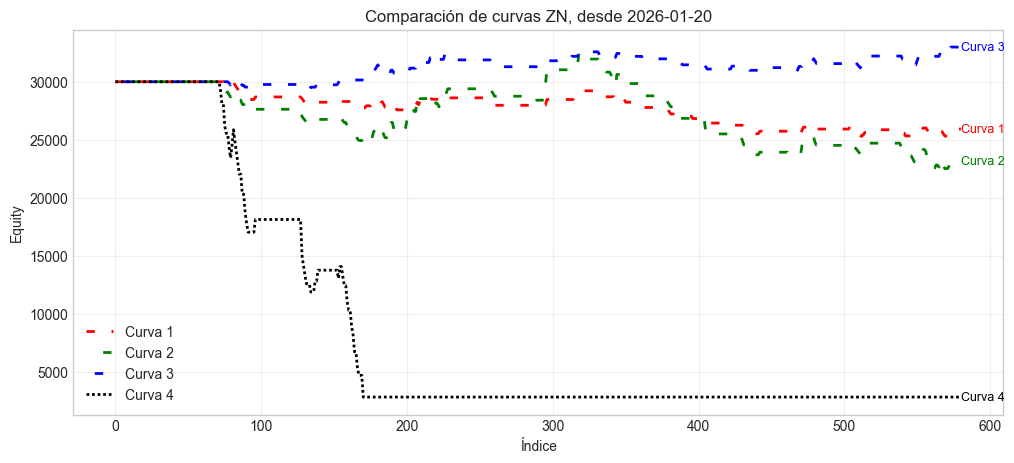

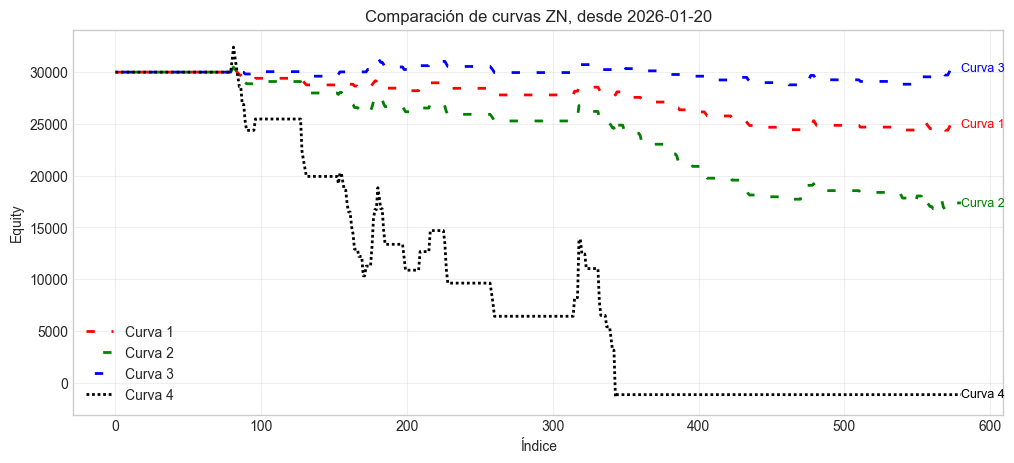

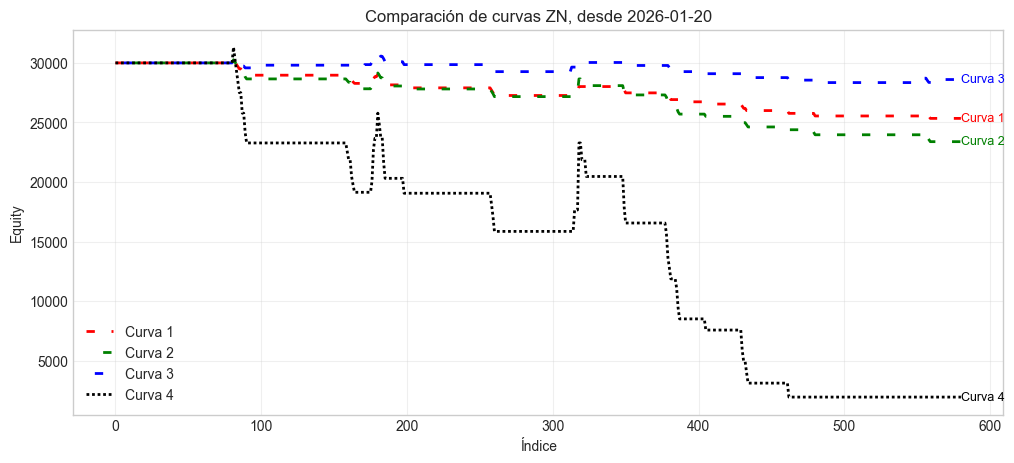

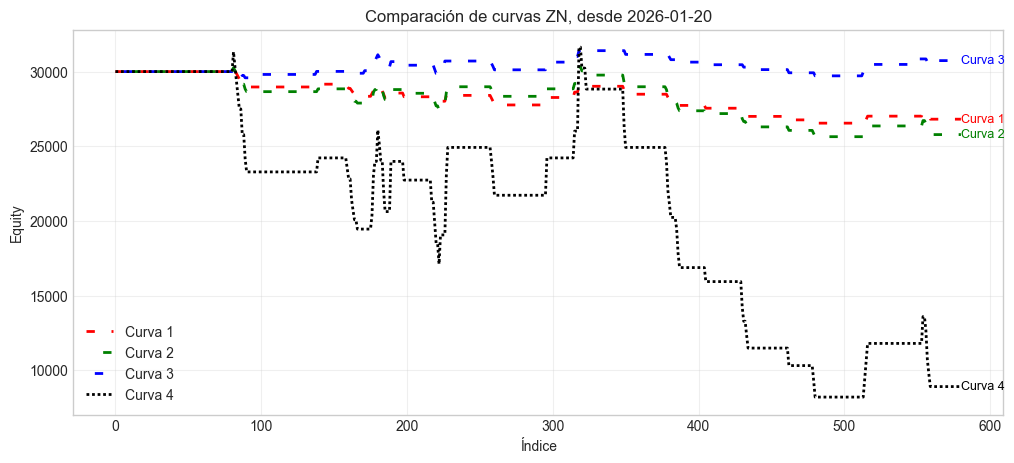


[ZN] mejor: df_ops + sizing  |  Calmar=0.861  |  Sharpe=0.855  |  MDD=4.9%  |  CAGR=4.2%  |  PnL=$2,987
block_size usado: 1  | n_blocks: 45
Median MDD      : -0.2%
Worst MDD (p5)  : -0.3%
Racha perd. med.: 4 trades
Racha perd. p95 : 7 trades


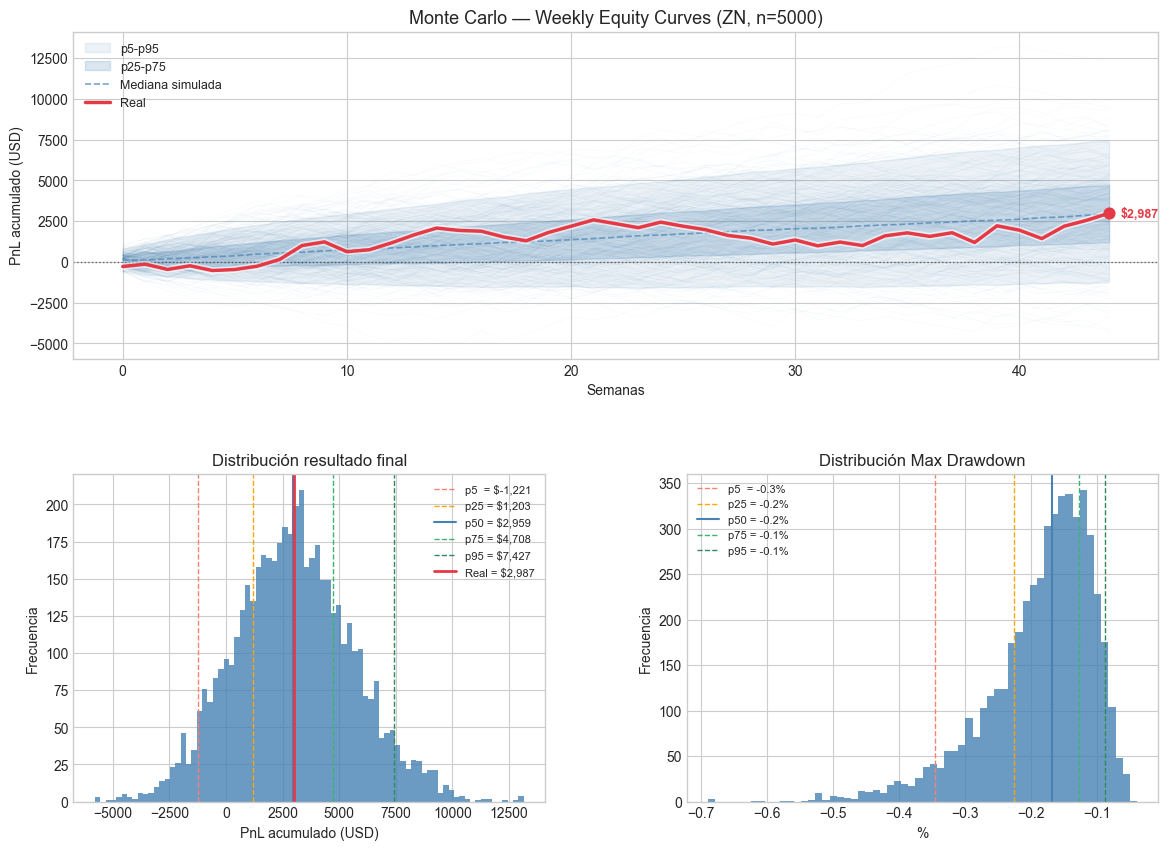

JSON actualizado: E:\Futuro\MLAlgoTrading\TradingBots\Models/best_per_asset.json


{'ZN': {'strat': 'df_ops',
  'backtest': 'sizing',
  'calmar': 0.8609,
  'sharpe': 0.8552,
  'max_dd': 0.0488,
  'cagr': 0.042,
  'equity_path': 'E:\\Futuro\\MLAlgoTrading\\TradingBots\\Models/zn/equity_best.parquet',
  'trades_path': 'E:\\Futuro\\MLAlgoTrading\\TradingBots\\Models/zn/trades_best.parquet'}}

In [29]:
backtest_grid_search(MODELS_DIR, ASSET, MINUTES, RETURN_HORIZON_MIN, start, end, True, False)

In [36]:
best = pd.read_json(f"{MODELS_DIR}/best_per_asset.json")

In [39]:
best.loc["pnl_final"].sum()

662531.8621

In [45]:
ASSET = symbols[12]
pd.read_parquet(f"{MODELS_DIR}/{ASSET}/equity_best.parquet")

,equity
0,50000.0
1,50000.0
2,50000.0
3,50000.0
4,50000.0
...,...
450,501375.0
451,501375.0
452,501375.0
453,501375.0


In [48]:
pd.read_parquet(f"{MODELS_DIR}/{ASSET}/trades_best.parquet")

,type,entry,exit,pnl_points,pnl_usd,datetime_exit,date
0,long,1092.265,1099.4375,7.1725,35862.5,2026-01-28 08:00:00+00:00,2026-01-28
1,long,1098.265,1104.8325,6.5675,32837.5,2026-01-28 16:00:00+00:00,2026-01-28
2,long,1098.765,1105.4550,6.6900,33450.0,2026-01-28 16:00:00+00:00,2026-01-28
3,long,1101.765,1109.3625,7.5975,37987.5,2026-01-29 16:00:00+00:00,2026-01-29
4,long,1100.765,1108.6000,7.8350,39175.0,2026-01-29 16:00:00+00:00,2026-01-29
5,long,1101.015,1108.6050,7.5900,37950.0,2026-01-29 16:00:00+00:00,2026-01-29
6,long,1094.265,1088.3550,-5.9100,-29550.0,2026-01-30 20:00:00+00:00,2026-01-30
7,short,1089.485,1080.1050,9.3800,46900.0,2026-02-02 08:00:00+00:00,2026-02-02
8,long,1087.265,1094.8800,7.6150,38075.0,2026-02-03 16:00:00+00:00,2026-02-03
9,long,1088.015,1095.4150,7.4000,37000.0,2026-02-03 16:00:00+00:00,2026-02-03
